In [16]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve

from adserve_sim.data.schema import LABEL
from adserve_sim.data.split import split_by_day
from adserve_sim.eval.distortion import STANDARD_SCENARIOS
from adserve_sim.eval.reliability import compare_scenarios, reliability_curve
from adserve_sim.features.build import add_time_features, feature_columns
from adserve_sim.models.train import baseline_metrics, train_model

# 1. Model on Avazu dataset

In [7]:
df = pd.read_parquet("../data/processed/avazu_sample.parquet")
split = split_by_day(df, val_days=1, test_days=2)

print(split.sizes)
print(split.base_rates)

{'train': 134010, 'validation': 26154, 'test': 39828}
{'train': 0.17351690172375195, 'validation': 0.15466085493614742, 'test': 0.1636034950286231}


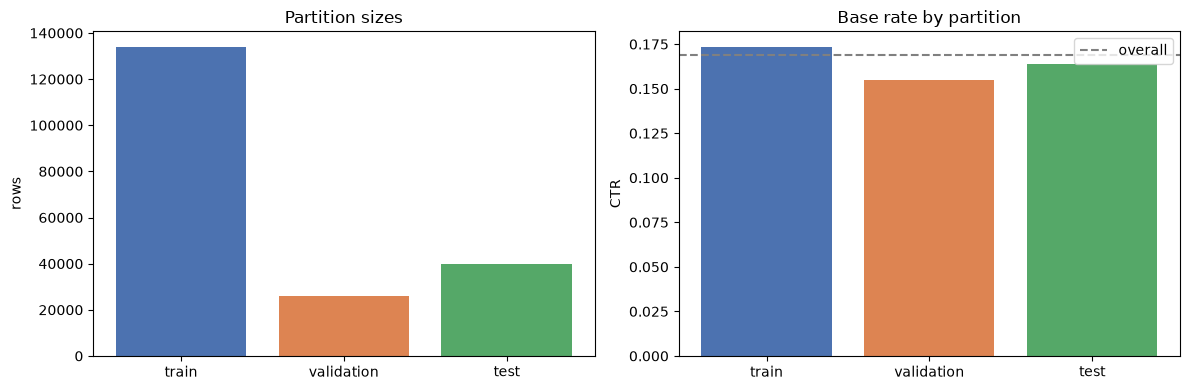

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sizes = pd.Series(split.sizes)
axes[0].bar(sizes.index, sizes.values, color=["#4c72b0", "#dd8452", "#55a868"])
axes[0].set_ylabel("rows")
axes[0].set_title("Partition sizes")

rates = pd.Series(split.base_rates)
axes[1].bar(rates.index, rates.values, color=["#4c72b0", "#dd8452", "#55a868"])
axes[1].axhline(df["click"].mean(), ls="--", c="grey", label="overall")
axes[1].set_ylabel("CTR")
axes[1].set_title("Base rate by partition")
axes[1].legend()

plt.tight_layout()
plt.show()

In [2]:
model, metrics = train_model(split, use_target_encoding=False, log_to_mlflow=True)

baseline = baseline_metrics(split)

print(f"baseline  log loss {baseline.log_loss:.4f}")
print(
    f"test      AUC {metrics['test'].auc:.4f}  "
    f"log loss {metrics['test'].log_loss:.4f}  "
    f"calibration gap {metrics['test'].calibration_gap:+.4f}"
)

0:	test: 0.6308305	best: 0.6308305 (0)	total: 773ms	remaining: 6m 25s
100:	test: 0.7431344	best: 0.7433837 (95)	total: 51s	remaining: 3m 21s
200:	test: 0.7450355	best: 0.7454252 (177)	total: 1m 35s	remaining: 2m 21s
300:	test: 0.7458917	best: 0.7460474 (293)	total: 2m 26s	remaining: 1m 36s
400:	test: 0.7467719	best: 0.7467834 (396)	total: 3m 27s	remaining: 51.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7468388193
bestIteration = 408

Shrink model to first 409 iterations.


2026/08/23 18:14:02 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/23 18:14:02 INFO mlflow.store.db.utils: Updating database tables
2026/08/23 18:14:04 INFO mlflow.tracking.fluent: Experiment with name 'ctr-baseline' does not exist. Creating a new experiment.


baseline  log loss 0.4459
test      AUC 0.7261  log loss 0.4007  calibration gap +0.0026


In [ ]:
test_matrix = add_time_features(split.test)
columns = feature_columns(use_target_encoding=False)

predictions = model.predict_proba(test_matrix[columns])[:, 1]
labels = split.test[LABEL].to_numpy()

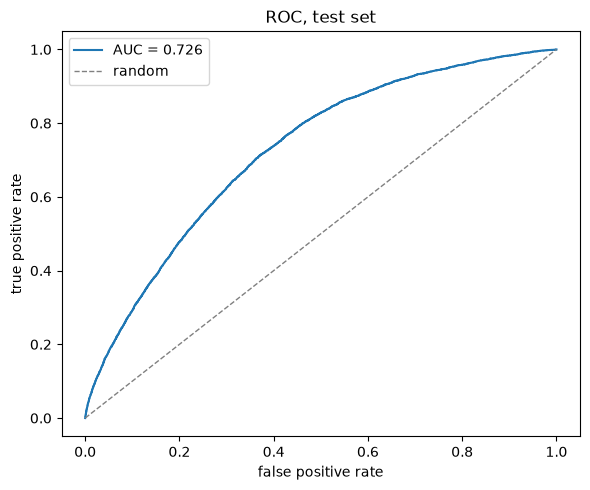

In [18]:
fpr, tpr, _ = roc_curve(labels, predictions)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {metrics['test'].auc:.3f}")
ax.plot([0, 1], [0, 1], ls="--", c="grey", lw=1, label="random")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC, test set")
ax.legend()
plt.tight_layout()
plt.show()

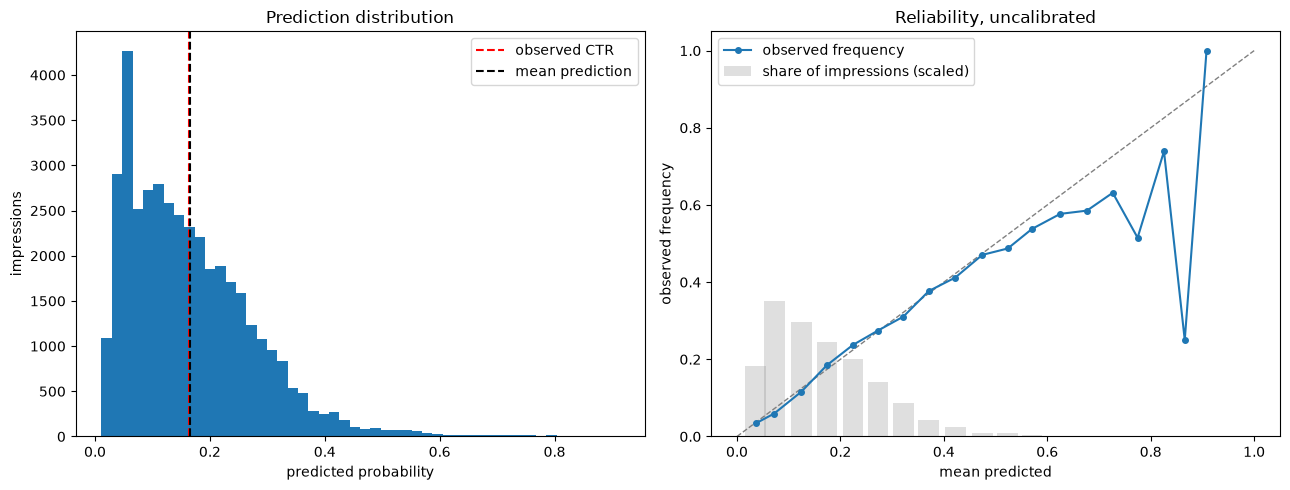

,mean_predicted,observed_frequency,weight
0,0.0361,0.0339,0.1142
1,0.0720,0.0596,0.2192
2,0.1242,0.1157,0.1851
3,0.1739,0.1848,0.1526
4,0.2241,0.2372,0.1251
5,0.2726,0.2746,0.0892
6,0.3218,0.3108,0.0542
7,0.3709,0.3769,0.0263
8,0.4221,0.4119,0.0148
9,0.4742,0.4706,0.0060


In [15]:
labels = split.test[LABEL].to_numpy()
curve = reliability_curve(labels, predictions, n_bins=20)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(predictions, bins=50)
axes[0].axvline(labels.mean(), ls="--", c="red", label="observed CTR")
axes[0].axvline(predictions.mean(), ls="--", c="black", label="mean prediction")
axes[0].set_xlabel("predicted probability")
axes[0].set_ylabel("impressions")
axes[0].set_title("Prediction distribution")
axes[0].legend()

axes[1].bar(
    curve.mean_predicted,
    curve.weight / curve.weight.max() * 0.35,
    width=0.04,
    alpha=0.25,
    color="grey",
    label="share of impressions (scaled)",
)
axes[1].plot([0, 1], [0, 1], ls="--", c="grey", lw=1)
axes[1].plot(
    curve.mean_predicted,
    curve.observed_frequency,
    marker="o",
    markersize=4,
    label="observed frequency",
)
axes[1].set_xlabel("mean predicted")
axes[1].set_ylabel("observed frequency")
axes[1].set_title("Reliability, uncalibrated")
axes[1].legend()

plt.tight_layout()
plt.show()

display(curve.to_frame().round(4))

### Baseline explanation

Three numbers, and the third is not what we expected at the beginning of the project.

| | |
|---|---|
| Test AUC | 0.726 |
| Test log loss | 0.4007 (baseline 0.4459) |
| Calibration gap | +0.0026 on a 16.4% base rate |

The model learns `log loss` beats the constant predictor by a clear margin, and
AUC of 0.73 on 10 days of a 200k sample is respectable. But it is **already
calibrated**. A gap of +0.0026 means the model over-predicts by about 1.6%
relative, and the reliability curve sits on the diagonal across the entire range
where predictions actually live.

That is not luck. CatBoost was fitted with `Logloss`, which is a *proper scoring
rule*, so it penalises wrong probabilities directly, not just wrong ordering. Also
early stopping fired at iteration 408 before the model could grow confident
enough to distort (or deep enogh to push probabilities toward 0/1). 
That familiar claim that boosted trees do so describes deep trees run to 
convergence without those two things.
Do the correct thing and you get correct probabilities.

The high tail is the one genuinely miscalibrated region: above 0.6 predicted,
observed frequency falls well below the line. But the histogram shows almost no
mass there, so it is a handful of impressions, not a systematic problem.

**Consequence for this project.** The plan was: train a model, find it
miscalibrated, fix it, measure what the fix is worth. There is nothing here to
fix. Running isotonic or Platt on this would move ECE by almost nothing and the
auction step would have no gap to price.

So the question has to be asked the other way round.


# 2. Miscalibrated model

Rather than hoping a model is broken, distort a good one by a known amount and
measure what each amount costs.

This is the stronger design, not a fallback. *"My model happened to be
miscalibrated and here is the fix"* is an anecdote whose size depends on which
model you happened to train. *"Here is the cost curve of miscalibration in an
auction"* is a controlled experiment, and it answers what the project actually
asks: what does being wrong about magnitude cost, once the score becomes a
price?

**How.** Not by multiplying the probability, that escapes `[0, 1]` and squashes
the distribution unevenly. The natural space is log-odds:



In [19]:
comparison = compare_scenarios(labels, predictions, STANDARD_SCENARIOS)
display(comparison.round(4))

,sharpness,shift,auc,log_loss,ece,calibration_gap,mean_prediction
scenario,,,,,,,
none,1.0,0.0,0.7261,0.4007,0.0099,0.0026,0.1662
over-predict,1.0,0.4,0.7261,0.4125,0.0587,0.0587,0.2223
under-predict,1.0,-0.4,0.7261,0.4090,0.0428,-0.0423,0.1214
overconfident,1.5,0.0,0.7261,0.4294,0.0658,-0.0628,0.1008
underconfident,0.6,0.0,0.7261,0.4358,0.0971,0.0970,0.2606


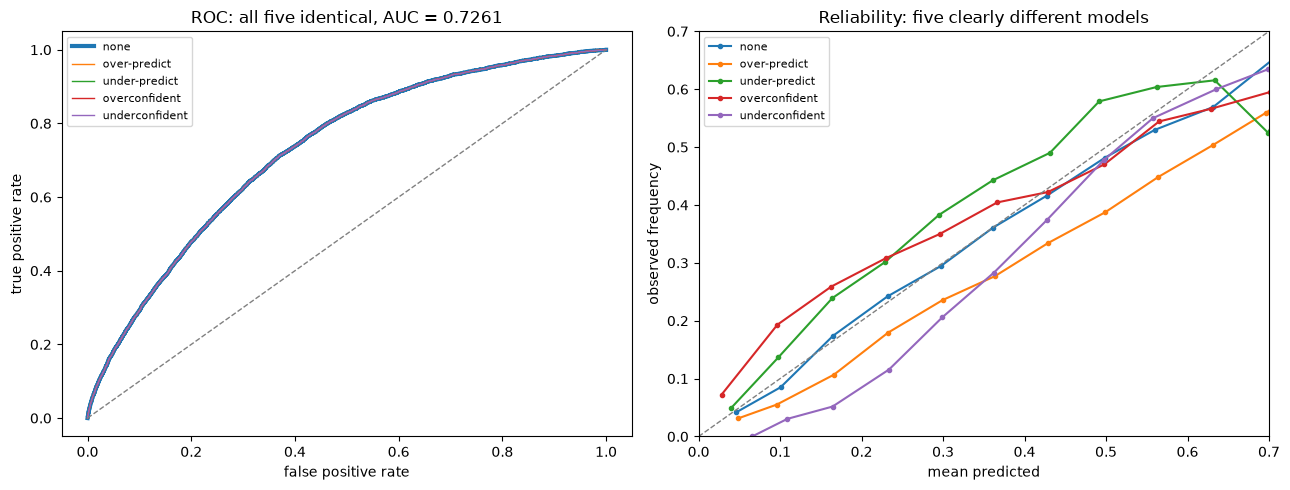

In [22]:
aucs = comparison["auc"].round(6).unique()
assert len(aucs) == 1, "distortions must not change the ranking"

colors = dict(zip(STANDARD_SCENARIOS, plt.cm.tab10.colors, strict=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, distortion in STANDARD_SCENARIOS.items():
    distorted = distortion.apply(predictions)

    fpr, tpr, _ = roc_curve(labels, distorted)
    axes[0].plot(fpr, tpr, lw=3 if name == "none" else 1, label=name)

    curve = reliability_curve(labels, distorted, n_bins=15)
    axes[1].plot(
        curve.mean_predicted,
        curve.observed_frequency,
        marker="o",
        markersize=3,
        label=name,
    )

axes[0].plot([0, 1], [0, 1], ls="--", c="grey", lw=1)
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title(f"ROC: all five identical, AUC = {aucs[0]:.4f}")
axes[0].legend(fontsize=8)

axes[1].plot([0, 0.7], [0, 0.7], ls="--", c="grey", lw=1)
axes[1].set_xlim(0, 0.7)
axes[1].set_ylim(0, 0.7)
axes[1].set_xlabel("mean predicted")
axes[1].set_ylabel("observed frequency")
axes[1].set_title("Reliability: five clearly different models")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

The left panel is five curves. We can see one, because they are identical,
every distortion is monotone, so ranking quality is untouched by construction.
A team tracking AUC would see one model here and nothing to investigate.

The right panel is the same five. A shift of +0.4 in log-odds moves mean
prediction from 16.4% to roughly 22%: a systematic over-prediction of about a
third, invisible on the left, unmissable on the right.

That gap is what the auction step prices. If `bid = value × pCTR`, a model
predicting 22% where the truth is 16.4% over-bids by a third on every impression
it wins — and the reason nobody catches it offline is the left-hand panel.